In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)
print('Imports Successfully!')

Imports Successfully!


In [2]:
DATA_PATH = "../data/processed/final_merged_source_labeled_dataset.csv" # todo: put in config

df = pd.read_csv(DATA_PATH)

META_COLS = ['company', 'date', 'quarter', 'layoff','same_quarter', 'next_quarter', 'layoff_same_quarter', 'layoff_next_quarter', 'layoff_same_or_next_quarter','source_pool']
FEATURE_COLS = [col for col in df.columns if col not in META_COLS]
TARGET_COL  = 'layoff'

n_companies  = df['company'].nunique()
n_rows_pos   = len(df[df['layoff'] == 1])
n_rows_neg   = len(df[df['layoff'] == 0])

print(f'Positive companies : {n_companies}')
print(f'Positive rows      : {n_rows_pos}')
print(f'Negative rows      : {n_rows_neg}')
print(f'Feature columns    : {len(FEATURE_COLS)}')
print(f'Quarters present   : {sorted(df["quarter"].unique())}')
df.head(5)

Positive companies : 5381
Positive rows      : 12047
Negative rows      : 17971
Feature columns    : 347
Quarters present   : ['2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1', '2026Q2']


,company,date,quarter,bs_Accounts Payable,bs_Accounts Receivable,bs_Accrued Interest Receivable,bs_Accumulated Depreciation,bs_Additional Paid In Capital,bs_Allowance For Doubtful Accounts Receivable,bs_Assets Held For Sale Current,...,fin_Tax Rate For Calcs,fin_Total Expenses,fin_Total Operating Income As Reported,fin_Total Other Finance Cost,fin_Total Revenue,fin_Total Unusual Items,fin_Total Unusual Items Excluding Goodwill,fin_Write Off,layoff,source_pool
0,RGA,2024-12-31,2024Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,layoff_tracked
1,RGA,2025-03-31,2025Q1,NaN,5.420000e+09,NaN,NaN,2.608000e+09,NaN,NaN,...,0.219512,4.920000e+09,NaN,NaN,5.289000e+09,NaN,NaN,NaN,1,layoff_tracked
2,RGA,2025-06-30,2025Q2,NaN,5.386000e+09,NaN,NaN,2.624000e+09,NaN,NaN,...,0.210000,5.215000e+09,NaN,NaN,5.556000e+09,NaN,NaN,NaN,1,layoff_tracked
3,RGA,2025-09-30,2025Q3,NaN,5.758000e+09,NaN,NaN,2.628000e+09,NaN,NaN,...,0.203000,5.909000e+09,NaN,NaN,6.229000e+09,NaN,NaN,NaN,1,layoff_tracked
4,RGA,2025-12-31,2025Q4,NaN,7.175000e+09,NaN,NaN,2.640000e+09,NaN,NaN,...,0.088235,6.098000e+09,NaN,NaN,6.608000e+09,NaN,NaN,NaN,1,layoff_tracked


In [3]:
# Combine real positives + negatives (randomly sampled) into a single dataframe for training/testing

presence_df = df[FEATURE_COLS].notna().astype(int)  # 1 if present, 0 if NaN
presence_df.columns = [f'HAS_{c}' for c in FEATURE_COLS]

# Drop zero-variance presence columns (allways 0 or 1)
# WHY? Because they don't provide any signal to distinguish between classes if they are always 0 or always 1.
pvar = presence_df.var()
presence_df = presence_df.loc[:, pvar > 0]
print(f"Presence features after removing zero variance: {presence_df.shape[1]} columns  ")

Presence features after removing zero variance: 347 columns  


In [4]:
numeric_df = df[FEATURE_COLS].copy()
col_medians = numeric_df.median()
numeric_df = numeric_df.fillna(col_medians)

# Drop any column still having all-NaN:
still_nan = numeric_df.columns[numeric_df.isnull().any()]
if len(still_nan) > 0:
    print(f"Dropping {len(still_nan)} columns with all-NaN values: {list(still_nan)}")
    numeric_df = numeric_df.drop(columns=still_nan)
# Do we need to drop HAS_ columns with all-NaN?
# No, they are binary indicators of presence, so they should not be dropped even if all 0 or 1 in one class.

# Drop zero variance numeric columns (constant value after median interpolation)
nvar= numeric_df.var()
numeric_df = numeric_df.loc[:, nvar > 0]
print(f"Numeric features after removing zero variance: {numeric_df.shape[1]} columns  ")


Numeric features after removing zero variance: 346 columns  


In [5]:
x = pd.concat([numeric_df.reset_index(drop=True), presence_df.reset_index(drop=True)], axis=1)
y = df['layoff'].reset_index(drop=True)

assert x.isnull().sum().sum() == 0, "There should be no NaN values in the final feature set"
print(f'Final feature set shape: {x.shape}')
print(f'feature matrix : {y.value_counts().to_dict()}')
print(f'No NaN values')

Final feature set shape: (30018, 693)
feature matrix : {0: 17971, 1: 12047}
No NaN values


In [6]:
# Stratified split — preserves 1:1 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale for distance/linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train label dist : {y_train.value_counts().to_dict()}')
print(f'Test  label dist : {y_test.value_counts().to_dict()}')

Train: 24014 rows  |  Test: 6004 rows
Train label dist : {0: 14377, 1: 9637}
Test  label dist : {0: 3594, 1: 2410}


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (name, model, use_scaled)
models = [
    ('Random Forest',      RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE), False),
    ('XGBoost',            XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False),
    ('Gradient Boosting',  GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    ('Logistic Regression',LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE), True),
    ('SVM',                SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE), True),
    ('KNN',                KNeighborsClassifier(n_neighbors=20), True),
]

results = []
for name, model, scaled in models:
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test

    cv_auc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    lbl = str(int(y_test.unique()[0])) if y_test.nunique() == 1 else '1'
    pos_rep = rep.get('1', rep.get('1.0', {}))

    results.append({
        'Model':          name,
        'CV AUC':         f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}",
        'CV AUC mean':    cv_auc.mean(),
        'CV AUC std':     cv_auc.std(),
        'Test AUC':       test_auc,
        'Accuracy':       rep['accuracy'],
        'Precision (1)':  pos_rep.get('precision', 0),
        'Recall (1)':     pos_rep.get('recall', 0),
        'F1 (1)':         pos_rep.get('f1-score', 0),
        '_model': model, '_scaled': scaled, '_y_pred': y_pred, '_y_prob': y_prob
    })
    print(f'{name:25s}  CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}  |  Test AUC: {test_auc:.3f}  |  Acc: {rep["accuracy"]:.3f}')

print('All models done')

Random Forest              CV AUC: 0.963 ± 0.003  |  Test AUC: 0.969  |  Acc: 0.917
XGBoost                    CV AUC: 0.969 ± 0.003  |  Test AUC: 0.975  |  Acc: 0.919
Gradient Boosting          CV AUC: 0.916 ± 0.005  |  Test AUC: 0.918  |  Acc: 0.843
Logistic Regression        CV AUC: 0.864 ± 0.002  |  Test AUC: 0.867  |  Acc: 0.781
SVM                        CV AUC: 0.912 ± 0.003  |  Test AUC: 0.925  |  Acc: 0.847
KNN                        CV AUC: 0.879 ± 0.003  |  Test AUC: 0.895  |  Acc: 0.815
All models done


Model Performance Summary:
              Model        CV AUC  Test AUC  Accuracy  Precision (1)  Recall (1)   F1 (1)
            XGBoost 0.969 ± 0.003  0.975191  0.918554       0.907856    0.887137 0.897377
      Random Forest 0.963 ± 0.003  0.969006  0.916722       0.907771    0.882158 0.894781
                SVM 0.912 ± 0.003  0.924892  0.846935       0.773578    0.874689 0.821032
  Gradient Boosting 0.916 ± 0.005  0.917716  0.843271       0.808225    0.799170 0.803672
                KNN 0.879 ± 0.003  0.895063  0.814624       0.765888    0.775104 0.770468
Logistic Regression 0.864 ± 0.002  0.866905  0.780646       0.696371    0.804149 0.746389


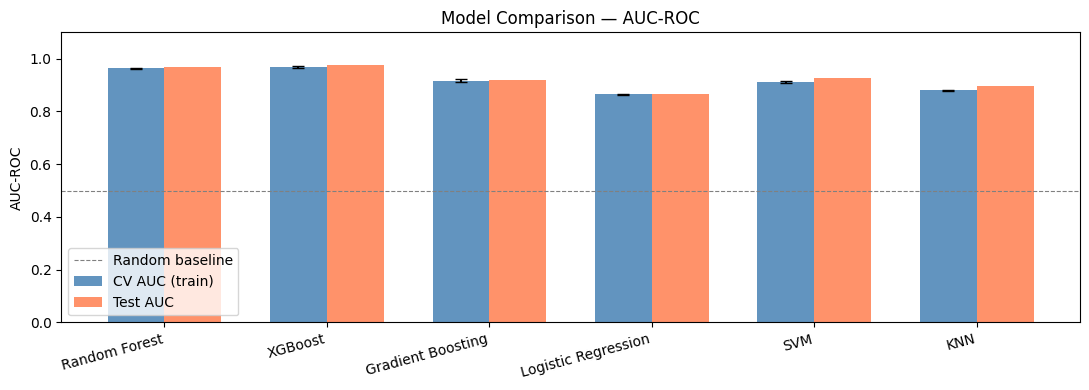

In [8]:
display_cols = ['Model','CV AUC','Test AUC','Accuracy','Precision (1)','Recall (1)','F1 (1)']
results_df = pd.DataFrame(results)[display_cols].sort_values('Test AUC', ascending=False).reset_index(drop=True)
print("Model Performance Summary:")
print(results_df.to_string(index=False))

# Bar chart: CV AUC vs Test AUC
cv_means = [r['CV AUC mean'] for r in results]
cv_stds  = [r['CV AUC std']  for r in results]
test_aucs = [r['Test AUC']   for r in results]
names     = [r['Model']      for r in results]

x_plt = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_plt - w/2, cv_means,  w, yerr=cv_stds, label='CV AUC (train)', color='steelblue', alpha=0.85, capsize=4)
ax.bar(x_plt + w/2, test_aucs, w, label='Test AUC', color='coral', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xticks(x_plt)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Comparison — AUC-ROC')
ax.legend()
plt.tight_layout()
plt.show()



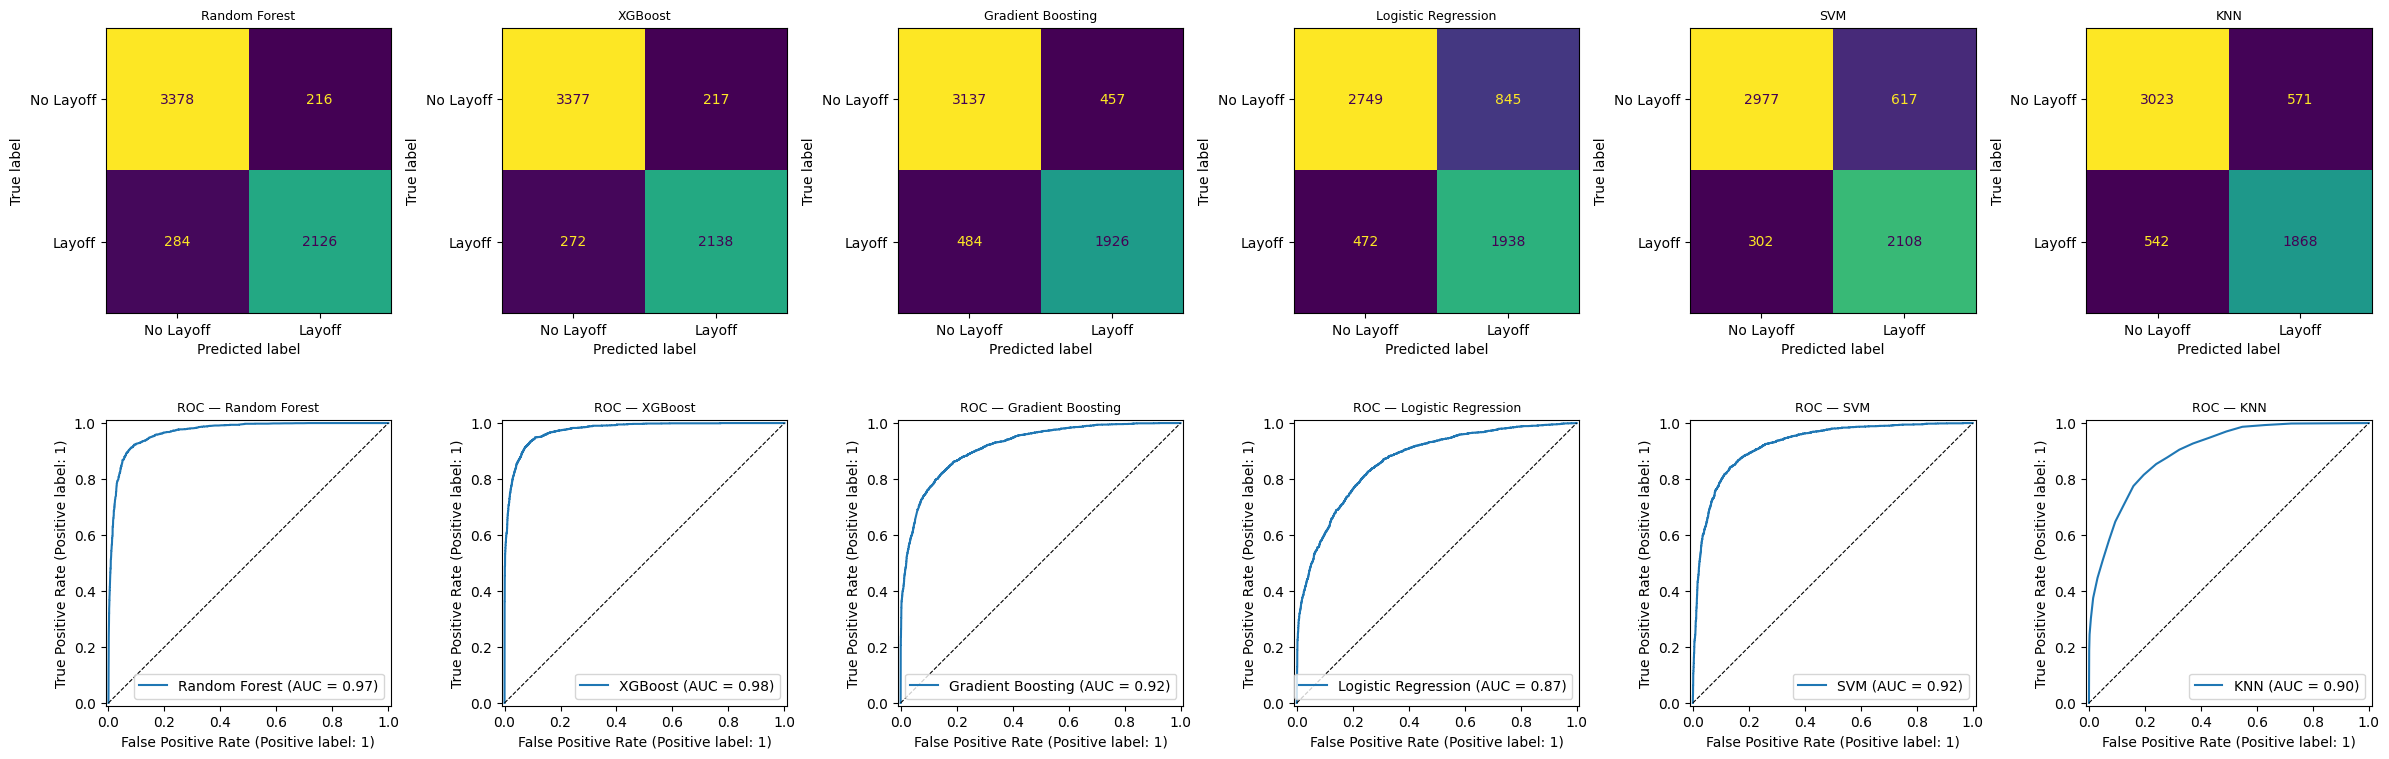

In [9]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
for i, r in enumerate(results):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, r['_y_pred']),
        display_labels=['No Layoff', 'Layoff']
    ).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(r['Model'], fontsize=9)

    RocCurveDisplay.from_predictions(y_test, r['_y_prob'], ax=axes[1, i], name=r['Model'])
    axes[1, i].plot([0,1],[0,1],'k--',linewidth=0.8)
    axes[1, i].set_title('ROC — ' + r['Model'], fontsize=9)

plt.tight_layout()
plt.show()

Feature importance from: XGBoost (Test AUC = 0.975)


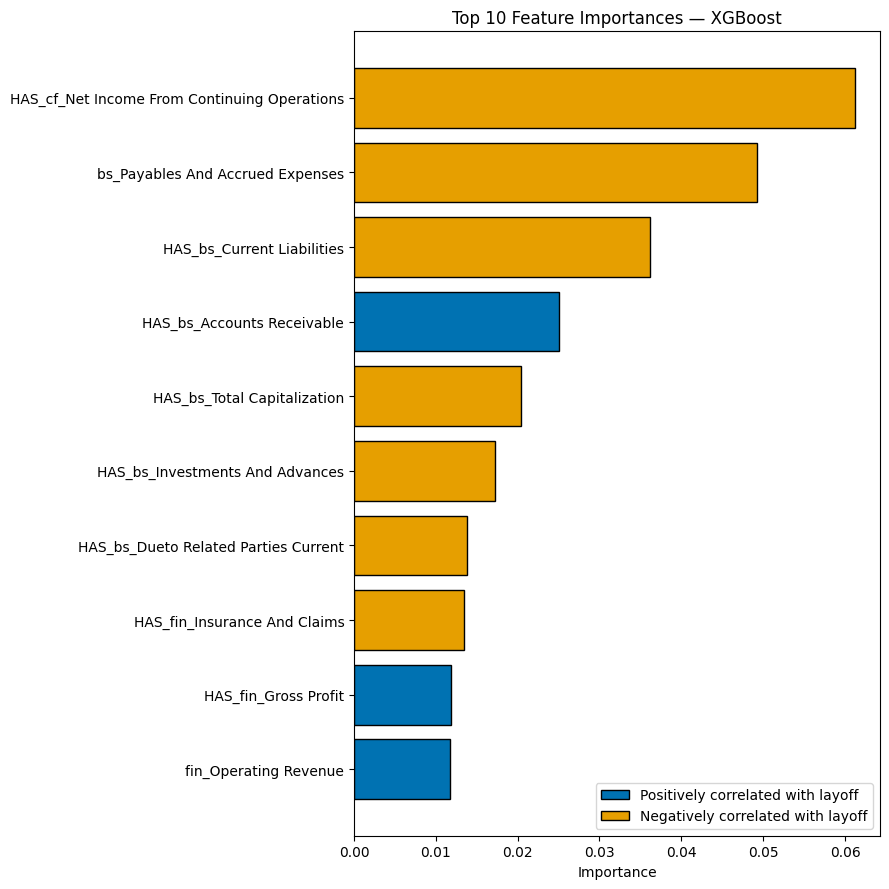

Top 10 features:
HAS_cf_Net Income From Continuing Operations    0.061215
bs_Payables And Accrued Expenses                0.049282
HAS_bs_Current Liabilities                      0.036201
HAS_bs_Accounts Receivable                      0.025107
HAS_bs_Total Capitalization                     0.020394
HAS_bs_Investments And Advances                 0.017277
HAS_bs_Dueto Related Parties Current            0.013776
HAS_fin_Insurance And Claims                    0.013489
HAS_fin_Gross Profit                            0.011865
fin_Operating Revenue                           0.011740


In [10]:
tree_results = [r for r in results if hasattr(r['_model'], 'feature_importances_')]
best = max(tree_results, key=lambda r: r['Test AUC'])
print(f'Feature importance from: {best["Model"]} (Test AUC = {best["Test AUC"]:.3f})')

importances = pd.Series(best['_model'].feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10)

# Direction of each feature's relationship to the target (correlation sign),
# since tree feature_importances_ only capture magnitude, not direction.
corr_with_target = x[top10.index].corrwith(y)
colors = corr_with_target.reindex(top10.index).apply(lambda c: '#0072B2' if c > 0 else '#E69F00')

fig, ax = plt.subplots(figsize=(9, 9))
top10_sorted = top10.sort_values()
ax.barh(top10_sorted.index, top10_sorted.values,
        color=colors.reindex(top10_sorted.index), edgecolor='black')
ax.set_title(f'Top 10 Feature Importances — {best["Model"]}')
ax.set_xlabel('Importance')

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#0072B2', edgecolor='black', label='Positively correlated with layoff'),
    Patch(facecolor='#E69F00', edgecolor='black', label='Negatively correlated with layoff'),
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top10.head(10).to_string())

In [11]:
best_overall = max(results, key=lambda r: r['Test AUC'])
print(f'=== Best Model: {best_overall["Model"]} ===')
print(f'Test AUC : {best_overall["Test AUC"]:.4f}')
print(f'CV AUC   : {best_overall["CV AUC"]}')
print()
print(classification_report(
    y_test, best_overall['_y_pred'],
    target_names=['No Layoff', 'Layoff'], zero_division=0
))

=== Best Model: XGBoost ===
Test AUC : 0.9752
CV AUC   : 0.969 ± 0.003

              precision    recall  f1-score   support

   No Layoff       0.93      0.94      0.93      3594
      Layoff       0.91      0.89      0.90      2410

    accuracy                           0.92      6004
   macro avg       0.92      0.91      0.91      6004
weighted avg       0.92      0.92      0.92      6004



In [12]:
best_model  = best_overall['_model']

mask       = df['layoff'] == 1
X_real     = x.loc[mask]
X_real_inp = scaler.transform(X_real) if scaled else X_real

df_scored = df.loc[mask, ['company', 'date', 'quarter']].copy()
df_scored['layoff_prob'] = best_model.predict_proba(X_real_inp)[:, 1]
df_scored['predicted']   = best_model.predict(X_real_inp)
df_scored = df_scored.sort_values('layoff_prob', ascending=False).reset_index(drop=True)

print('Top 100-scored company-quarters:')
df_scored.head(100)

Top 100-scored company-quarters:


,company,date,quarter,layoff_prob,predicted
0,NWL,2025-09-30,2025Q3,0.999354,1
1,SNDK,2025-06-30,2025Q2,0.999109,1
2,NWL,2025-12-31,2025Q4,0.999039,1
3,PEP,2025-12-31,2025Q4,0.998855,1
4,PEP,2025-09-30,2025Q3,0.998794,1
...,...,...,...,...,...
95,HPE,2026-04-30,2026Q2,0.996885,1
96,VIAV,2026-03-31,2026Q1,0.996872,1
97,RDW,2025-06-30,2025Q2,0.996797,1
98,CWH,2025-09-30,2025Q3,0.996748,1


Saved quadrant_scatter.png — upload this file into Canva as an image element.


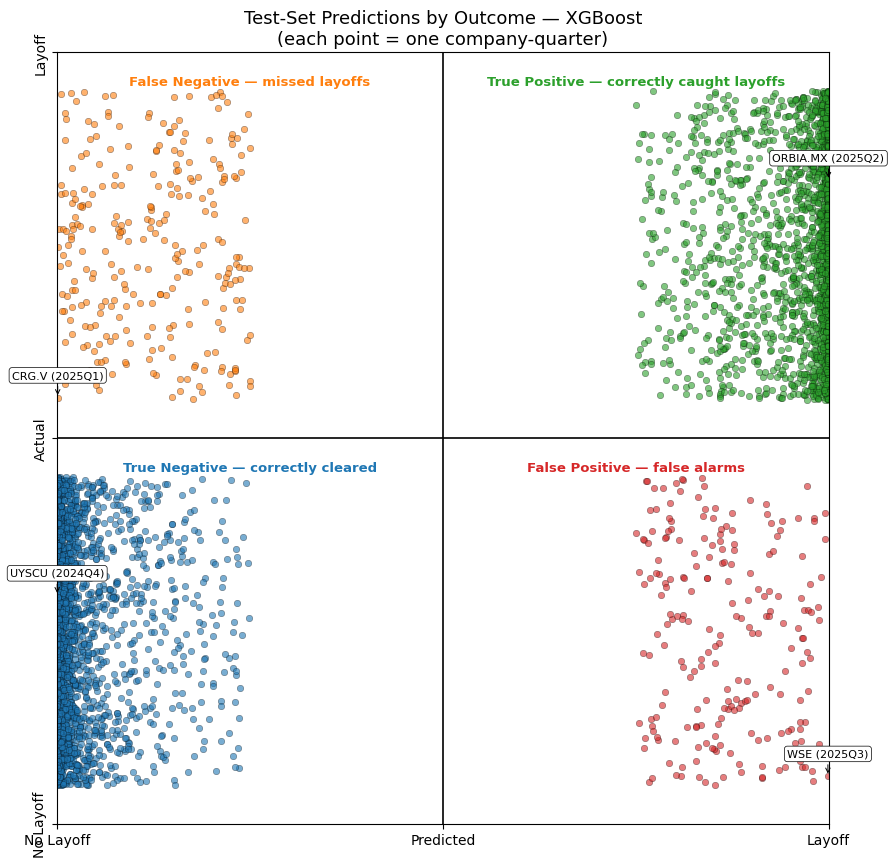

In [15]:
# Align company / quarter info with the test set (same index as X_test/y_test)
test_info = df.loc[X_test.index, ['company', 'quarter']].reset_index(drop=True)
y_true = y_test.reset_index(drop=True)
y_pred = pd.Series(best_overall['_y_pred'])
y_prob = pd.Series(best_overall['_y_prob'])

outcome = np.select(
    [
        (y_true == 1) & (y_pred == 1),
        (y_true == 0) & (y_pred == 1),
        (y_true == 1) & (y_pred == 0),
        (y_true == 0) & (y_pred == 0),
    ],
    ['TP', 'FP', 'FN', 'TN'], default='NA'
)

plot_df = test_info.copy()
plot_df['predicted_prob'] = y_prob
plot_df['outcome'] = outcome

colors = {'TP': '#2ca02c', 'FP': '#d62728', 'FN': '#ff7f0e', 'TN': '#1f77b4'}
labels_full = {
    'TP': 'True Positive — correctly caught layoffs',
    'FP': 'False Positive — false alarms',
    'FN': 'False Negative — missed layoffs',
    'TN': 'True Negative — correctly cleared',
}
# Each quadrant occupies one corner of a single square axes:
#   x in [0, 0.5) = predicted "No Layoff" | x in [0.5, 1] = predicted "Layoff"
#   y in [0, 0.5) = actual    "No Layoff" | y in [0.5, 1] = actual    "Layoff"
quadrant_bounds = {
    'FN': ((0.0, 0.5), (0.5, 1.0)),   # actual=Layoff,    predicted=No Layoff  -> top-left
    'TP': ((0.5, 1.0), (0.5, 1.0)),   # actual=Layoff,    predicted=Layoff     -> top-right
    'TN': ((0.0, 0.5), (0.0, 0.5)),   # actual=No Layoff, predicted=No Layoff  -> bottom-left
    'FP': ((0.5, 1.0), (0.0, 0.5)),   # actual=No Layoff, predicted=Layoff     -> bottom-right
}

np.random.seed(RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 9))

for label, ((x0, x1), (y0, y1)) in quadrant_bounds.items():
    sub = plot_df[plot_df['outcome'] == label]
    n = len(sub)
    if n == 0:
        continue

    # scale predicted_prob (0-1) into this quadrant's x-range, add jitter in y
    x_vals = x0 + sub['predicted_prob'].values * (x1 - x0)
    y_vals = np.random.uniform(y0 + 0.05, y1 - 0.05, size=n)

    ax.scatter(x_vals, y_vals, color=colors[label], alpha=0.6, s=22,
               edgecolor='black', linewidth=0.3, label=f"{label} (n={n})")

    # Label the single most notable point in this quadrant
    standout_pos = sub['predicted_prob'].idxmax() if label in ('TP', 'FP') else sub['predicted_prob'].idxmin()
    standout = sub.loc[standout_pos]
    loc = sub.index.get_loc(standout_pos)
    ax.annotate(
        f"{standout['company']} ({standout['quarter']})",
        xy=(x_vals[loc], y_vals[loc]),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8,
        arrowprops=dict(arrowstyle='->', color='black', lw=0.7),
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', lw=0.5)
    )

    # Quadrant name, centered in its region
    ax.text((x0 + x1) / 2, y1 - 0.03, labels_full[label],
            ha='center', va='top', fontsize=9.5, fontweight='bold', color=colors[label])

# Divider lines splitting the square into 4 quadrants
ax.axvline(0.5, color='black', linewidth=1.2)
ax.axhline(0.5, color='black', linewidth=1.2)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(['No Layoff', 'Predicted', 'Layoff'])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['No Layoff', 'Actual', 'Layoff'], rotation=90, va='center')
ax.set_aspect('equal')
ax.set_title(f'Test-Set Predictions by Outcome — {best_overall["Model"]}\n(each point = one company-quarter)', fontsize=13)

plt.tight_layout()
plt.savefig('quadrant_scatter.png', dpi=300, bbox_inches='tight')
print('Saved quadrant_scatter.png — upload this file into Canva as an image element.')
plt.show()